# NB05: 유동인구 데이터 집계

**목적**: 36개월 행정동별 유동인구를 시간대/성별/연령별로 집계, 주문 잠재 고객군 식별

**입력**: `00_data/민간데이터/T22-*/T22/T22_GG_ADMI_FLOWPOP_*.csv` (36 files)  
**출력**: `processed/flow_pop_agg.parquet` (동별 유동인구 집계)

In [1]:
import pandas as pd
import numpy as np
import glob
from pathlib import Path

BASE = Path(r"E:\서울시데이터경진대회\Aero-Logic-Seoul")
RAW = BASE / "00_data"
OUT = BASE / "processed"

# 유동인구 파일 탐색
fp_files = sorted(glob.glob(str(RAW / "LOCAL__" / "*.csv")))
print(f"총 유동인구 파일: {len(fp_files)}개")

총 유동인구 파일: 12개


## 1. 전체 파일 로드 및 합치기

파일당 ~7만 행으로 카드매출 대비 작아 전체 로드 가능

In [31]:
# 전체 파일 로드
dfs = []
for fpath in fp_files:
    try:
        # 먼저 cp949로 읽기 시도
        df = pd.read_csv(fpath, encoding='cp949', index_col=False)
    except UnicodeDecodeError:
        # cp949 디코딩 에러 발생 시 utf-8-sig로 재시도
        df = pd.read_csv(fpath, encoding='utf-8-sig', index_col=False)
    # 파일명에서 연월 추출
    fname = Path(fpath).stem  # T22_GG_ADMI_FLOWPOP_202301_성남시
    ym = fname.split("_")[3]  # 202301
    df["ym"] = ym
    dfs.append(df)

crosswalk = pd.read_csv(r"E:\서울시데이터경진대회\Aero-Logic-Seoul\processed\admin_code_crosswalk.csv")

# 코드는 무조건 문자열(str)로 맞춰두는 것이 안전합니다! (앞에 0이 빠지는 현상 방지)
crosswalk["SHP_ADM_CD"] = crosswalk["SHP_ADM_CD"].astype(str)
crosswalk["CSV_ADMI_CD"] = crosswalk["CSV_ADMI_CD"].astype(str)

print("✅ 매핑 테이블 로드 완료!")

df_fp = pd.concat(dfs, ignore_index=True)
print(f"전체 행 수: {len(df_fp):,}")
print(f"기간: {df_fp['ym'].min()} ~ {df_fp['ym'].max()}")
print(f"행정동 수: {df_fp['행정동코드'].nunique()}")
print(f"\n컬럼: {df_fp.columns.tolist()}")

rename_dict = {
    "남자0세부터9세생활인구수": "M_00_CNT",
    "남자10세부터14세생활인구수": "M_10_CNT",
    "남자15세부터19세생활인구수": "M_15_CNT",
    "남자20세부터24세생활인구수": "M_20_CNT",
    "남자25세부터29세생활인구수": "M_25_CNT",
    "남자30세부터34세생활인구수": "M_30_CNT",
    "남자35세부터39세생활인구수": "M_35_CNT",
    "남자40세부터44세생활인구수": "M_40_CNT",
    "남자45세부터49세생활인구수": "M_45_CNT",
    "남자50세부터54세생활인구수": "M_50_CNT",
    "남자55세부터59세생활인구수": "M_55_CNT",
    "남자60세부터64세생활인구수": "M_60_CNT",
    "남자65세부터69세생활인구수": "M_65_CNT",
    "남자70세이상생활인구수": "M_70_CNT",
    
    "여자0세부터9세생활인구수": "F_00_CNT",
    "여자10세부터14세생활인구수": "F_10_CNT",
    "여자15세부터19세생활인구수": "F_15_CNT",
    "여자20세부터24세생활인구수": "F_20_CNT",
    "여자25세부터29세생활인구수": "F_25_CNT",
    "여자30세부터34세생활인구수": "F_30_CNT",
    "여자35세부터39세생활인구수": "F_35_CNT",
    "여자40세부터44세생활인구수": "F_40_CNT",
    "여자45세부터49세생활인구수": "F_45_CNT",
    "여자50세부터54세생활인구수": "F_50_CNT",
    "여자55세부터59세생활인구수": "F_55_CNT",
    "여자60세부터64세생활인구수": "F_60_CNT",
    "여자65세부터69세생활인구수": "F_65_CNT",
    "여자70세이상생활인구수": "F_70_CNT",
    
    # 추가로 공통 컬럼도 영문으로 통일하고 싶으시다면 아래 주석을 해제하세요.
    # "기준일ID": "ETL_YMD",
    "시간대구분": "TIME_CD",
    "총생활인구수": "TOTAL_POP_ORG"
}

df_fp = df_fp.rename(columns=rename_dict)
df_fp = df_fp.drop(columns=['?"기준일ID"'])

✅ 매핑 테이블 로드 완료!
전체 행 수: 3,693,812
기간: 202501 ~ 202512
행정동 수: 424

컬럼: ['기준일ID', '시간대구분', '행정동코드', '총생활인구수', '남자0세부터9세생활인구수', '남자10세부터14세생활인구수', '남자15세부터19세생활인구수', '남자20세부터24세생활인구수', '남자25세부터29세생활인구수', '남자30세부터34세생활인구수', '남자35세부터39세생활인구수', '남자40세부터44세생활인구수', '남자45세부터49세생활인구수', '남자50세부터54세생활인구수', '남자55세부터59세생활인구수', '남자60세부터64세생활인구수', '남자65세부터69세생활인구수', '남자70세이상생활인구수', '여자0세부터9세생활인구수', '여자10세부터14세생활인구수', '여자15세부터19세생활인구수', '여자20세부터24세생활인구수', '여자25세부터29세생활인구수', '여자30세부터34세생활인구수', '여자35세부터39세생활인구수', '여자40세부터44세생활인구수', '여자45세부터49세생활인구수', '여자50세부터54세생활인구수', '여자55세부터59세생활인구수', '여자60세부터64세생활인구수', '여자65세부터69세생활인구수', '여자70세이상생활인구수', 'ym', '?"기준일ID"']


In [35]:
df_fp = df_fp.drop(columns='기준일ID')

In [36]:
df_fp.head()

,TIME_CD,행정동코드,TOTAL_POP_ORG,M_00_CNT,M_10_CNT,M_15_CNT,M_20_CNT,M_25_CNT,M_30_CNT,M_35_CNT,...,F_30_CNT,F_35_CNT,F_40_CNT,F_45_CNT,F_50_CNT,F_55_CNT,F_60_CNT,F_65_CNT,F_70_CNT,ym
0,0,11110515,13959.2812,481.4116,306.7564,478.2017,357.3834,397.8554,361.7199,474.9342,...,453.7294,628.7862,683.5943,727.1302,618.3577,572.4571,473.0731,344.2641,1022.5939,202501
1,0,11110530,14230.5596,343.2194,152.5419,449.6299,551.2311,564.9371,466.4311,546.0382,...,578.3579,608.6689,622.1655,724.4159,641.8814,553.9168,499.1170,270.3996,873.3966,202501
2,0,11110540,3409.7726,58.5555,44.8674,107.5601,273.7226,103.7417,96.4308,131.6848,...,96.3902,116.8875,144.3649,134.9030,147.8925,150.1466,132.2848,93.3248,256.0581,202501
3,0,11110550,12816.3213,310.6309,240.8591,377.7566,417.1609,338.8140,330.5938,459.8556,...,412.9928,455.2826,532.2241,673.5003,573.0154,617.7934,455.7202,381.3082,1082.2851,202501
4,0,11110560,18662.7186,638.8311,462.0873,484.2466,617.8459,461.8934,389.0284,586.5398,...,474.2178,702.8572,727.9927,800.2534,792.7561,974.9772,893.7486,565.8544,1770.1419,202501


In [41]:
# 1. 원본 데이터(df_fp)의 행정동코드도 문자열로 변환 (필수!)
df_fp['행정동코드'] = df_fp['행정동코드'].astype(str)

# 2. 매핑 테이블(crosswalk)과 병합
df_fp = pd.merge(
    df_fp,
    crosswalk,
    left_on='행정동코드',   # 유동인구 데이터의 코드 컬럼
    right_on='CSV_ADMI_CD', # 크로스워크의 행안부 코드 컬럼
    how='inner'             # inner: 서울시 크로스워크에 있는 동만 남김
)

# 필요하다면 중복되는 행정동코드 컬럼 하나를 지워도 좋습니다 (선택)
# df_mapped = df_mapped.drop(columns=['CSV_ADMI_CD'])

print(f"✅ 매핑 완료! 최종 데이터 행 수: {len(df_fp):,}")
print(f"매핑된 구 목록: {df_fp['GU_NM'].unique()}")

# 결과 샘플 확인
display(df_fp.head())

✅ 매핑 완료! 최종 데이터 행 수: 3,606,693
매핑된 구 목록: ['종로구' '중구' '용산구' '성동구' '광진구' '동대문구' '중랑구' '성북구' '강북구' '도봉구' '노원구' '은평구'
 '서대문구' '마포구' '양천구' '강서구' '구로구' '금천구' '영등포구' '동작구' '관악구' '서초구' '강남구' '송파구'
 '강동구']


,TIME_CD,행정동코드,TOTAL_POP_ORG,M_00_CNT,M_10_CNT,M_15_CNT,M_20_CNT,M_25_CNT,M_30_CNT,M_35_CNT,...,F_70_CNT,ym,total_pop,male_pop,female_pop,young_pop,SHP_ADM_CD,CSV_ADMI_CD,GU_NM,DONG_NM
0,0,11110515,13959.2812,481.4116,306.7564,478.2017,357.3834,397.8554,361.7199,474.9342,...,1022.5939,202501,13959.2828,6122.9096,7836.3732,5960.9493,11010720,11110515,종로구,청운효자동
1,0,11110530,14230.5596,343.2194,152.5419,449.6299,551.2311,564.9371,466.4311,546.0382,...,873.3966,202501,14230.5577,6513.1245,7717.4332,7152.4036,11010530,11110530,종로구,사직동
2,0,11110540,3409.7726,58.5555,44.8674,107.5601,273.7226,103.7417,96.4308,131.6848,...,256.0581,202501,3409.7720,1720.6193,1689.1527,1659.8776,11010540,11110540,종로구,삼청동
3,0,11110550,12816.3213,310.6309,240.8591,377.7566,417.1609,338.8140,330.5938,459.8556,...,1082.2851,202501,12816.3205,5905.6046,6910.7159,5310.0997,11010550,11110550,종로구,부암동
4,0,11110560,18662.7186,638.8311,462.0873,484.2466,617.8459,461.8934,389.0284,586.5398,...,1770.1419,202501,18662.7173,8446.8726,10215.8447,6877.3796,11010560,11110560,종로구,평창동


## 2. 성별/연령대 합산 → 동별-시간대 총 유동인구

In [42]:
# 성별/연령 컬럼 식별 (M_10_CNT ~ M_70_CNT, F_10_CNT ~ F_70_CNT)
male_cols = [c for c in df_fp.columns if c.startswith("M_") and c.endswith("_CNT")]
female_cols = [c for c in df_fp.columns if c.startswith("F_") and c.endswith("_CNT")]
pop_cols = male_cols + female_cols

print(f"남성 연령대: {male_cols}")
print(f"여성 연령대: {female_cols}")

# 총 유동인구 계산
df_fp["total_pop"] = df_fp[pop_cols].sum(axis=1)
df_fp["male_pop"] = df_fp[male_cols].sum(axis=1)
df_fp["female_pop"] = df_fp[female_cols].sum(axis=1)

# 배달 주문 핵심 연령대 (20~40대) 유동인구
young_cols = [c for c in pop_cols if any(c.startswith(f"{g}_{a}") for g in ["M","F"] for a in ["20","25","30","35","40","45"])]
df_fp["young_pop"] = df_fp[young_cols].sum(axis=1)

print(f"\n배달 핵심 연령(20~40대) 컬럼: {len(young_cols)}개")
print(f"전체 유동인구 평균: {df_fp['total_pop'].mean():,.0f}")
print(f"20~40대 유동인구 비율: {df_fp['young_pop'].sum() / df_fp['total_pop'].sum():.1%}")

남성 연령대: ['M_00_CNT', 'M_10_CNT', 'M_15_CNT', 'M_20_CNT', 'M_25_CNT', 'M_30_CNT', 'M_35_CNT', 'M_40_CNT', 'M_45_CNT', 'M_50_CNT', 'M_55_CNT', 'M_60_CNT', 'M_65_CNT', 'M_70_CNT']
여성 연령대: ['F_00_CNT', 'F_10_CNT', 'F_15_CNT', 'F_20_CNT', 'F_25_CNT', 'F_30_CNT', 'F_35_CNT', 'F_40_CNT', 'F_45_CNT', 'F_50_CNT', 'F_55_CNT', 'F_60_CNT', 'F_65_CNT', 'F_70_CNT']

배달 핵심 연령(20~40대) 컬럼: 12개
전체 유동인구 평균: 23,928
20~40대 유동인구 비율: 49.4%


## 3. 동별 유동인구 밀집도 지수 산출 (최근 12개월)

In [44]:
# 최근 12개월 필터
recent_months = sorted(df_fp["ym"].unique())[-12:]
recent = df_fp[df_fp["ym"].isin(recent_months)]

# 동별 집계
pop_by_dong = (
    recent.groupby("CSV_ADMI_CD")
    .agg(
        avg_daily_total=("total_pop", "mean"),
        avg_daily_young=("young_pop", "mean"),
        peak_hour_pop=("total_pop", "max"),
        dong_nm=("DONG_NM", "first"),
    )
    .reset_index()
)

# 0-1 정규화
for col in ["avg_daily_total", "avg_daily_young"]:
    vmin, vmax = pop_by_dong[col].min(), pop_by_dong[col].max()
    pop_by_dong[f"{col}_norm"] = (pop_by_dong[col] - vmin) / (vmax - vmin)

# 유동인구 밀집도 지수 (전체 0.5 + 2040대 0.5)
pop_by_dong["flow_pop_index"] = (
    0.5 * pop_by_dong["avg_daily_total_norm"]
    + 0.5 * pop_by_dong["avg_daily_young_norm"]
)

print(f"동별 유동인구 지수 (최근 12개월: {recent_months[0]}~{recent_months[-1]}):")
print(pop_by_dong.nlargest(10, "flow_pop_index")[["CSV_ADMI_CD", "dong_nm", "avg_daily_total", "flow_pop_index"]])

동별 유동인구 지수 (최근 12개월: 202501~202512):
    CSV_ADMI_CD      dong_nm  avg_daily_total  flow_pop_index
359    11680640         역삼1동    100547.020246        1.000000
279    11560540          여의동     98417.139501        0.911496
208    11440660          서교동     71538.612789        0.691166
267    11545510          가산동     60948.453405        0.582328
333    11650530         서초3동     65217.061300        0.562105
8      11110615  종로1·2·3·4가동     62307.771741        0.555516
189    11410585          신촌동     56354.962757        0.540785
411    11740685           길동     60285.137792        0.470169
40     11170625         한강로동     51711.738301        0.468989
360    11680650         역삼2동     53604.815785        0.448678


## 4. 시간대별 유동인구 패턴 (Tableau 시간대 필터용)

In [45]:
# 동별-시간대별 유동인구 (Tableau 애니메이션용)
hourly_pop = (
    recent.groupby(["CSV_ADMI_CD", "TIME_CD"])
    .agg(avg_total_pop=("total_pop", "mean"), avg_young_pop=("young_pop", "mean"))
    .reset_index()
)

print(f"시간대별 유동인구 패턴: {len(hourly_pop)} rows")
print(f"시간대(TIME_CD) 범위: {sorted(hourly_pop['TIME_CD'].unique())}")

시간대별 유동인구 패턴: 9936 rows
시간대(TIME_CD) 범위: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


## 5. 시각 검증 + 저장

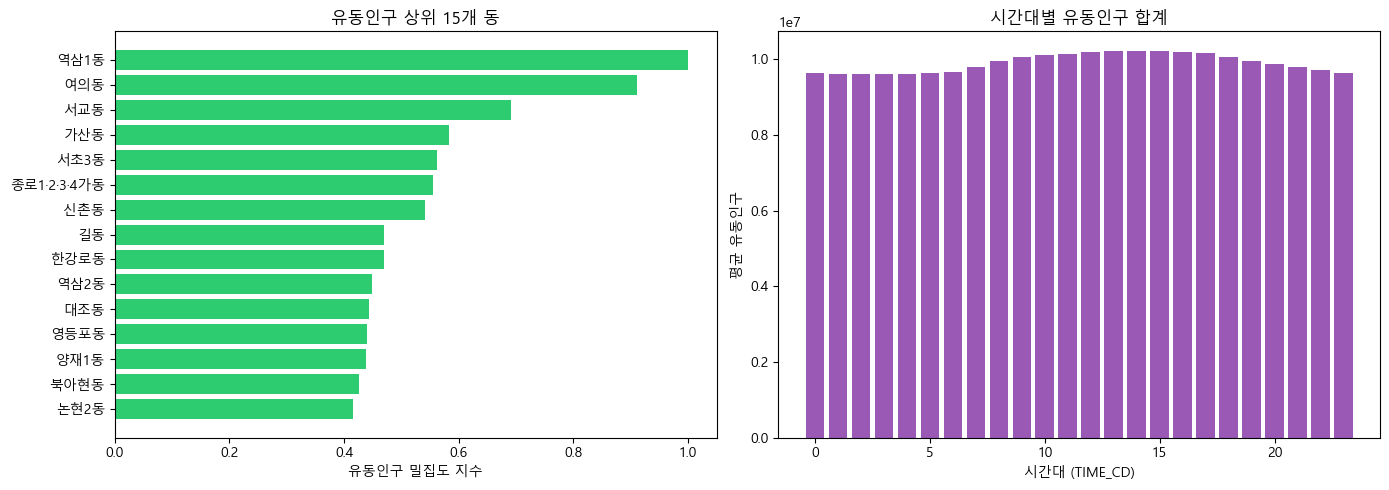

In [46]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 동별 유동인구 지수 상위 15개
top15 = pop_by_dong.nlargest(15, "flow_pop_index")
axes[0].barh(
    top15["dong_nm"][::-1],
    top15["flow_pop_index"][::-1],
    color="#2ecc71",
)
axes[0].set_xlabel("유동인구 밀집도 지수")
axes[0].set_title("유동인구 상위 15개 동")

# 오른쪽: 시간대별 전체 유동인구 패턴
hourly_total = hourly_pop.groupby("TIME_CD")["avg_total_pop"].sum()
axes[1].bar(hourly_total.index, hourly_total.values, color="#9b59b6")
axes[1].set_xlabel("시간대 (TIME_CD)")
axes[1].set_ylabel("평균 유동인구")
axes[1].set_title("시간대별 유동인구 합계")

plt.tight_layout()
plt.show()

In [47]:
# 저장
pop_by_dong.to_parquet(OUT / "flow_pop_agg.parquet", index=False)
hourly_pop.to_parquet(OUT / "flow_pop_hourly.parquet", index=False)

print("저장 완료:")
print(f"  - flow_pop_agg.parquet ({len(pop_by_dong)} rows) - 동별 유동인구 지수")
print(f"  - flow_pop_hourly.parquet ({len(hourly_pop)} rows) - 동별-시간대별 유동인구")

저장 완료:
  - flow_pop_agg.parquet (414 rows) - 동별 유동인구 지수
  - flow_pop_hourly.parquet (9936 rows) - 동별-시간대별 유동인구
